# Debugging Front Properties

In [1]:
# imports
from importlib import reload
import os

import numpy as np
import h5py
import xarray
import pandas

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
import matplotlib.gridspec as gridspec
import seaborn as sns

from skimage import morphology

from wrangler.plotting import cutout
from wrangler.ogcm import llc as wr_llc
from wrangler.preproc import pp_ogcm

from fronts.dbof import utils as dbof_utils
from fronts.dbof import io as dbof_io
from fronts.finding import dev as finding_dev
from fronts.finding import params as finding_params
from fronts.properties import views

# DBOF_dev

In [2]:
dbof_dev_file = '../fronts/runs/dbof/dev/llc4320_dbof_dev.json'

# Load up 

In [3]:
dbof_tbl = dbof_io.load_main_table(dbof_dev_file)

Read main table: /home/xavier/Projects/Oceanography/data/OGCM/DBOF/DBOF_dev/DBOF_dev.parquet


# An example

In [4]:
UID = 132796899894254531

In [5]:
idbof = dbof_utils.series_from_UID(dbof_tbl, UID)
idbof

lat                       9.893684
lon                       74.53125
row                           8403
col                           5369
datetime       2012-01-31 00:00:00
UID             132796899894254531
V                             True
SSTK                          True
SSH                           True
SSS                           True
SSSs                         False
Fs                            True
Divb2                         True
OW                            True
SSHs                         False
U                             True
b                             True
DivSST2                       True
divergence                    True
strain_rate                   True
DivSSS2                       True
vorticity                     True
Cu                            True
Name: 290277, dtype: object

## Grab the fields

In [6]:
fields = ['b', 'Divb2', 'Fs', 'afnorm_divergence', 'afnorm_strain_rate',
              'fnorm_vorticity','Cu', 'L', 'SSTK', 'U', 'V']
field_data = dbof_utils.grab_fields(dbof_dev_file, fields, UID,  required=True)
field_data.keys()

Read main table: /home/xavier/Projects/Oceanography/data/OGCM/DBOF/DBOF_dev/DBOF_dev.parquet
Grabbing fields for UID: 132796899894254531


dict_keys(['b', 'Divb2', 'Fs', 'afnorm_divergence', 'afnorm_strain_rate', 'fnorm_vorticity', 'Cu', 'L', 'SSTK', 'U', 'V'])

## Density

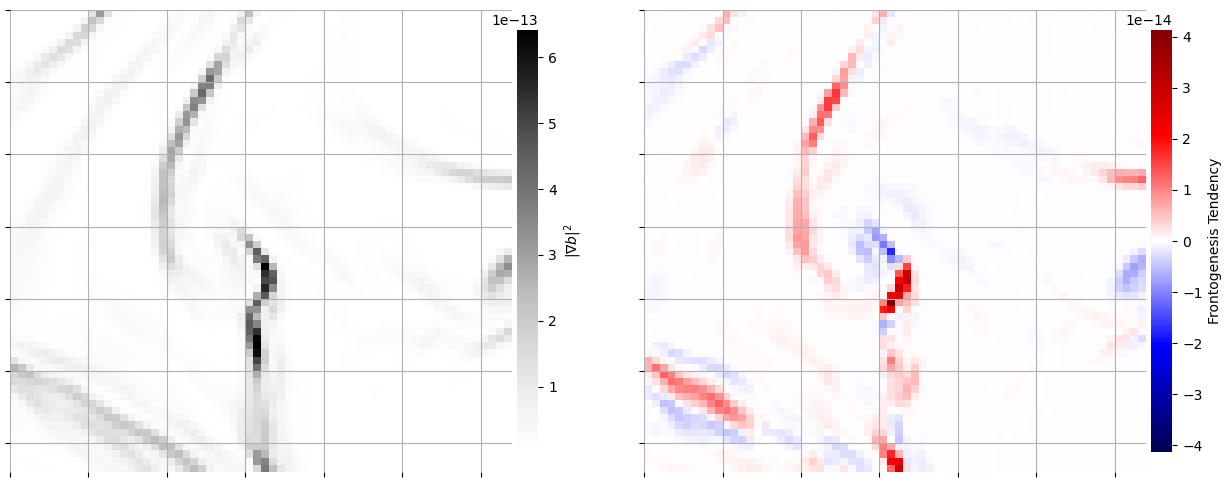

In [16]:
reload(views)
#
fsz = (15,6)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fsz)

#_ = views.show_field('b', field_data['b']*100, ax=ax1)
_ = views.show_field('Divb2', field_data['Divb2'], ax=ax1)
_ = views.show_field('Fs', field_data['Fs'], ax=ax2)
#
plt.show()

## Examine the currents

Velocity magnitude range: 0.082 to 0.760
Mean velocity magnitude: 0.359


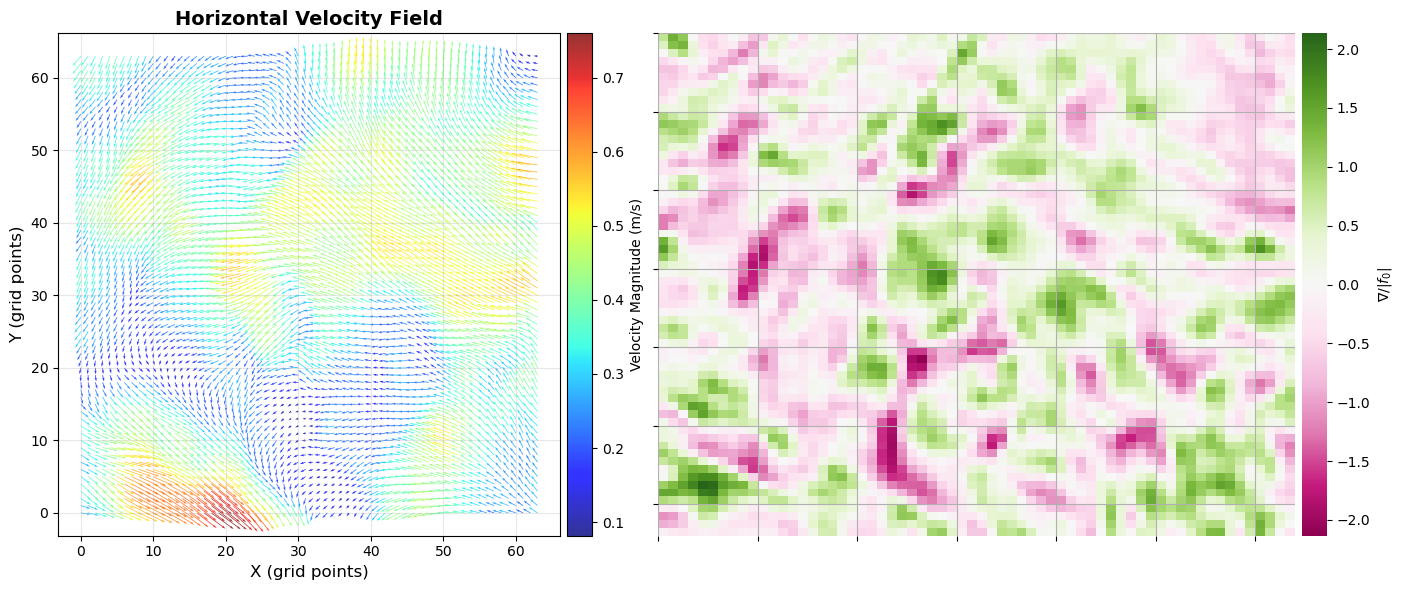

In [17]:
reload(views)
#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fsz)

_ = views.plot_velocities(field_data['U'], field_data['V'],ax=ax1)
_ = views.show_field('afnorm_divergence', field_data['afnorm_divergence'], ax=ax2)
#
plt.tight_layout()
plt.show()

## $\nabla \cdot (U,V)$

Velocity magnitude range: 0.082 to 0.760
Mean velocity magnitude: 0.359


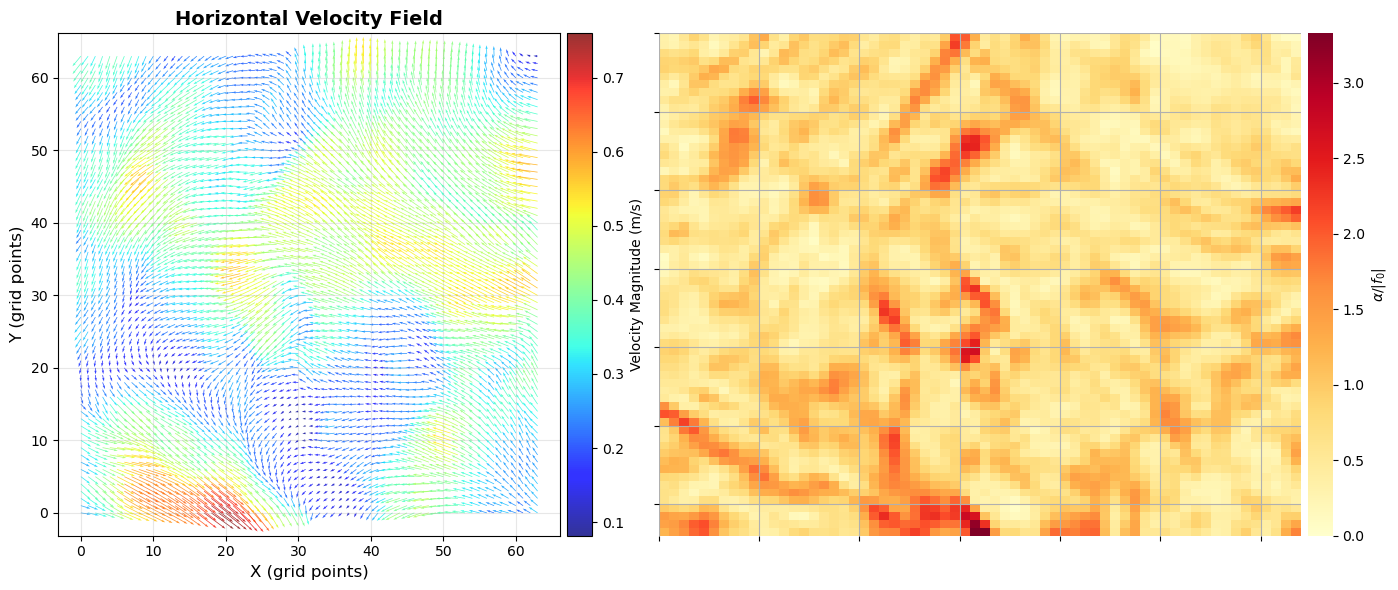

In [18]:
reload(views)
#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fsz)

_ = views.plot_velocities(field_data['U'], field_data['V'],ax=ax1)
_ = views.show_field('afnorm_strain_rate', field_data['afnorm_strain_rate'], ax=ax2)
#
plt.tight_layout()
plt.show()